In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Pandas Data/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [ ]:
df['room_per_house'] = df['total_rooms'] / df['households']
df['bedroom_per_house'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_house'] = df['population'] / df['households']

<Axes: >

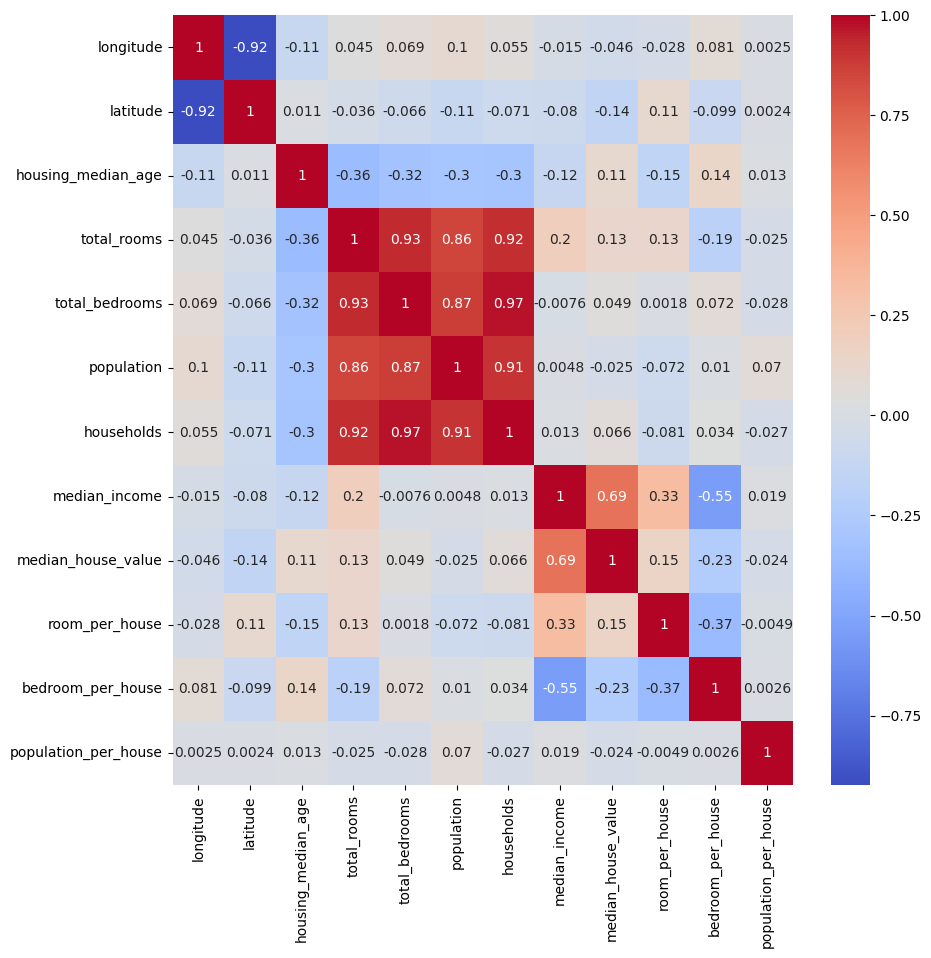

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap((df.drop(['ocean_proximity'],axis =1)).corr(),annot=True,cmap = 'coolwarm')

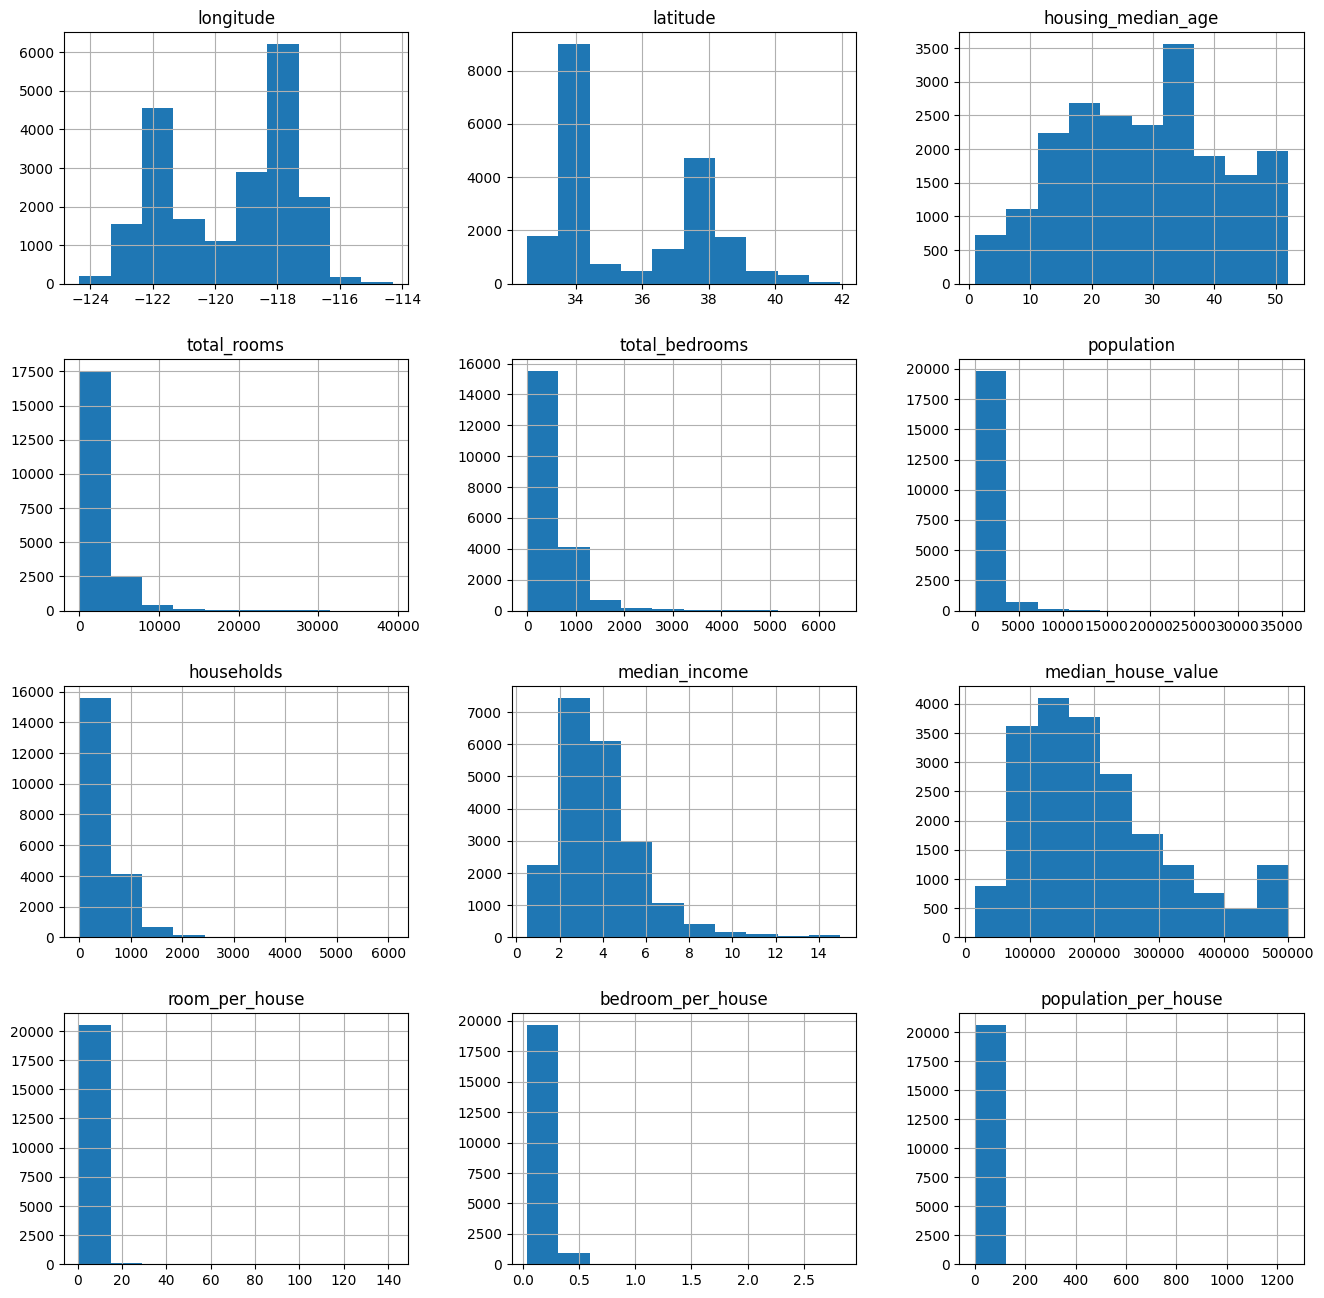

In [ ]:
df.hist(figsize=(16,16))
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

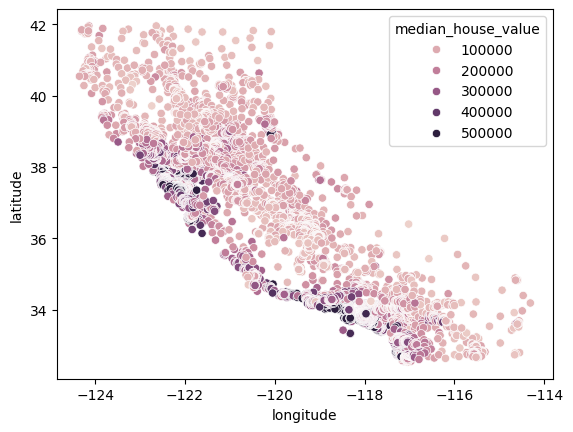

In [ ]:
sns.scatterplot(x='longitude',y='latitude',data=df,hue='median_house_value')

In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop('median_house_value',axis=1)
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,room_per_house,bedroom_per_house,population_per_house
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN,5.017657,0.200576,3.691814
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN,4.473545,0.232703,1.738095
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN,5.645833,0.174486,2.723214
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN,4.002817,0.258269,3.994366
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND,6.268421,0.180940,2.300000
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN,6.395349,0.166993,3.178891


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ohe = ColumnTransformer(transformers = [
    ('OHE', OneHotEncoder(sparse_output=False,drop='first'),[8])
],remainder='passthrough')

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
pipe_rfr = Pipeline([
    ('OHE',ohe),
    ('model_rfr',rfr)
])

In [ ]:
pipe_lr = Pipeline([
    ('OHE',ohe),
    ('std',std_scaler),
    ('model_lr',lr)
])

In [ ]:
pipe_dtr = Pipeline([
    ('OHE',ohe),
    ('std',std_scaler),
    ('model_dtr',dtr)
])

In [ ]:
pipe_rfr.fit(X_train,y_train)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [8])])),
                ('model_rfr', RandomForestRegressor(random_state=42))])

In [ ]:
pipe_lr.fit(X_train,y_train)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [8])])),
                ('std', StandardScaler()), ('model_lr', LinearRegression())])

In [ ]:
pipe_dtr.fit(X_train,y_train)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [8])])),
                ('std', StandardScaler()),
                ('model_dtr', DecisionTreeRegressor(random_state=42))])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model_rfr__n_estimators': [100, 200, 300],
    'model_rfr__max_depth': [10, 15, 20, None],
    'model_rfr__min_samples_split': [2, 5, 10],
    'model_rfr__min_samples_leaf': [1, 2, 4],
    'model_rfr__max_features': ['sqrt', 'log2']
}

# The original 'rf' is no longer needed as we'll tune the model within the pipeline.
# rf = RandomForestRegressor(random_state=42)

# Pass the entire pipeline to RandomizedSearchCV
search = RandomizedSearchCV(pipe_rfr, param_grid, n_iter=20, cv=5,
                            scoring='r2', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print("Best CV R2:", search.best_score_)

Best Params: {'model_rfr__n_estimators': 200, 'model_rfr__min_samples_split': 2, 'model_rfr__min_samples_leaf': 1, 'model_rfr__max_features': 'log2', 'model_rfr__max_depth': None}
Best CV R2: 0.8137549576368442


In [ ]:
from sklearn.model_selection import cross_val_score

best_model = search.best_estimator_
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R2: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV R2: 0.814 ± 0.003


In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pipelines = {
    'Linear Regression': pipe_lr,
    'Decision Tree': pipe_dtr,
    'Random Forest (Tuned)': best_model
}

print(f"{'Model':<25} {'Train R2':>10} {'Test R2':>10} {'RMSE':>12}")
print("-" * 60)
for name, pipe in pipelines.items():
    train_r2 = pipe.score(X_train, y_train)
    test_r2 = pipe.score(X_test, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    print(f"{name:<25} {train_r2:>10.3f} {test_r2:>10.3f} {rmse:>12.2f}")

Model                       Train R2    Test R2         RMSE
------------------------------------------------------------
Linear Regression              0.658      0.597     72668.54
Decision Tree                  1.000      0.589     73362.52
Random Forest (Tuned)          0.975      0.812     49669.29


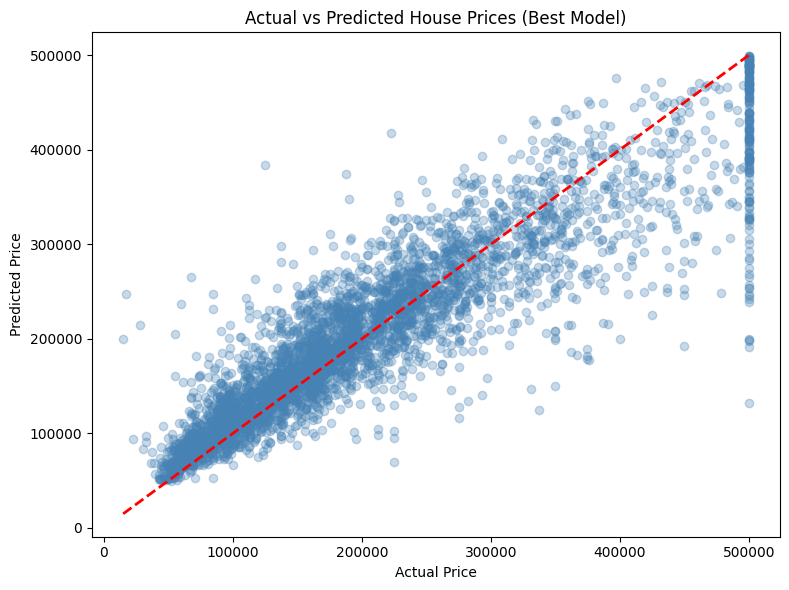

In [ ]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Best Model)")
plt.tight_layout()
plt.show()

In [ ]:
print(f"Train R2: {best_model.score(X_train, y_train):.3f}")
print(f"Test  R2: {best_model.score(X_test, y_test):.3f}")
# Gap > 0.10 means overfitting is still a concern

Train R2: 0.975
Test  R2: 0.812


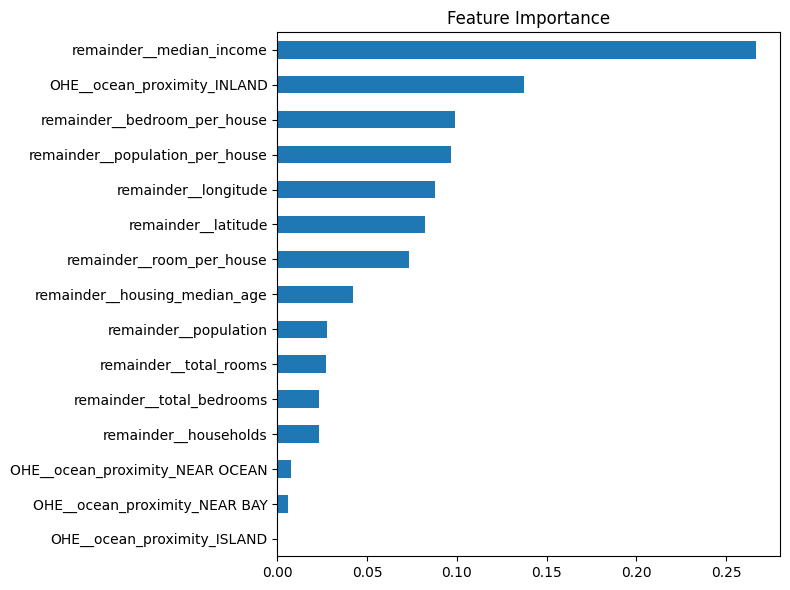

In [33]:
feature_names = (best_model.named_steps['OHE']
                 .get_feature_names_out())

importances = pd.Series(
    best_model.named_steps['model_rfr'].feature_importances_,
    index=feature_names
)

importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()